In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
data=pd.read_csv("Admission_Predict.csv")
data

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


In [4]:
data.shape

(400, 9)

In [5]:
data.drop("Serial No.",axis=1)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,0.82
396,325,107,3,3.0,3.5,9.11,1,0.84
397,330,116,4,5.0,4.5,9.45,1,0.91
398,312,103,3,3.5,4.0,8.78,0,0.67


In [7]:
data.columns=data.columns.str.strip()

In [8]:
def LocalEnc(x):
    if(x>=0.75):
        return 1
    else:
        return 0
data["Chance of Admit"]=data["Chance of Admit"].apply(LocalEnc)

In [9]:
data

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,1
1,2,324,107,4,4.0,4.5,8.87,1,1
2,3,316,104,3,3.0,3.5,8.00,1,0
3,4,322,110,3,3.5,2.5,8.67,1,1
4,5,314,103,2,2.0,3.0,8.21,0,0
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,1
396,397,325,107,3,3.0,3.5,9.11,1,1
397,398,330,116,4,5.0,4.5,9.45,1,1
398,399,312,103,3,3.5,4.0,8.78,0,0


In [10]:
x=data[["GRE Score","University Rating","CGPA"]]
y=data["Chance of Admit"]
x

,GRE Score,University Rating,CGPA
0,337,4,9.65
1,324,4,8.87
2,316,3,8.00
3,322,3,8.67
4,314,2,8.21
...,...,...,...
395,324,3,9.04
396,325,3,9.11
397,330,4,9.45
398,312,3,8.78


In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

In [12]:
gini_classifier=DecisionTreeClassifier(criterion="gini",max_depth=4)
entropy_classifier=DecisionTreeClassifier(criterion="entropy",max_depth=4)

In [15]:
gini_classifier.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=4)

In [16]:
entropy_classifier.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

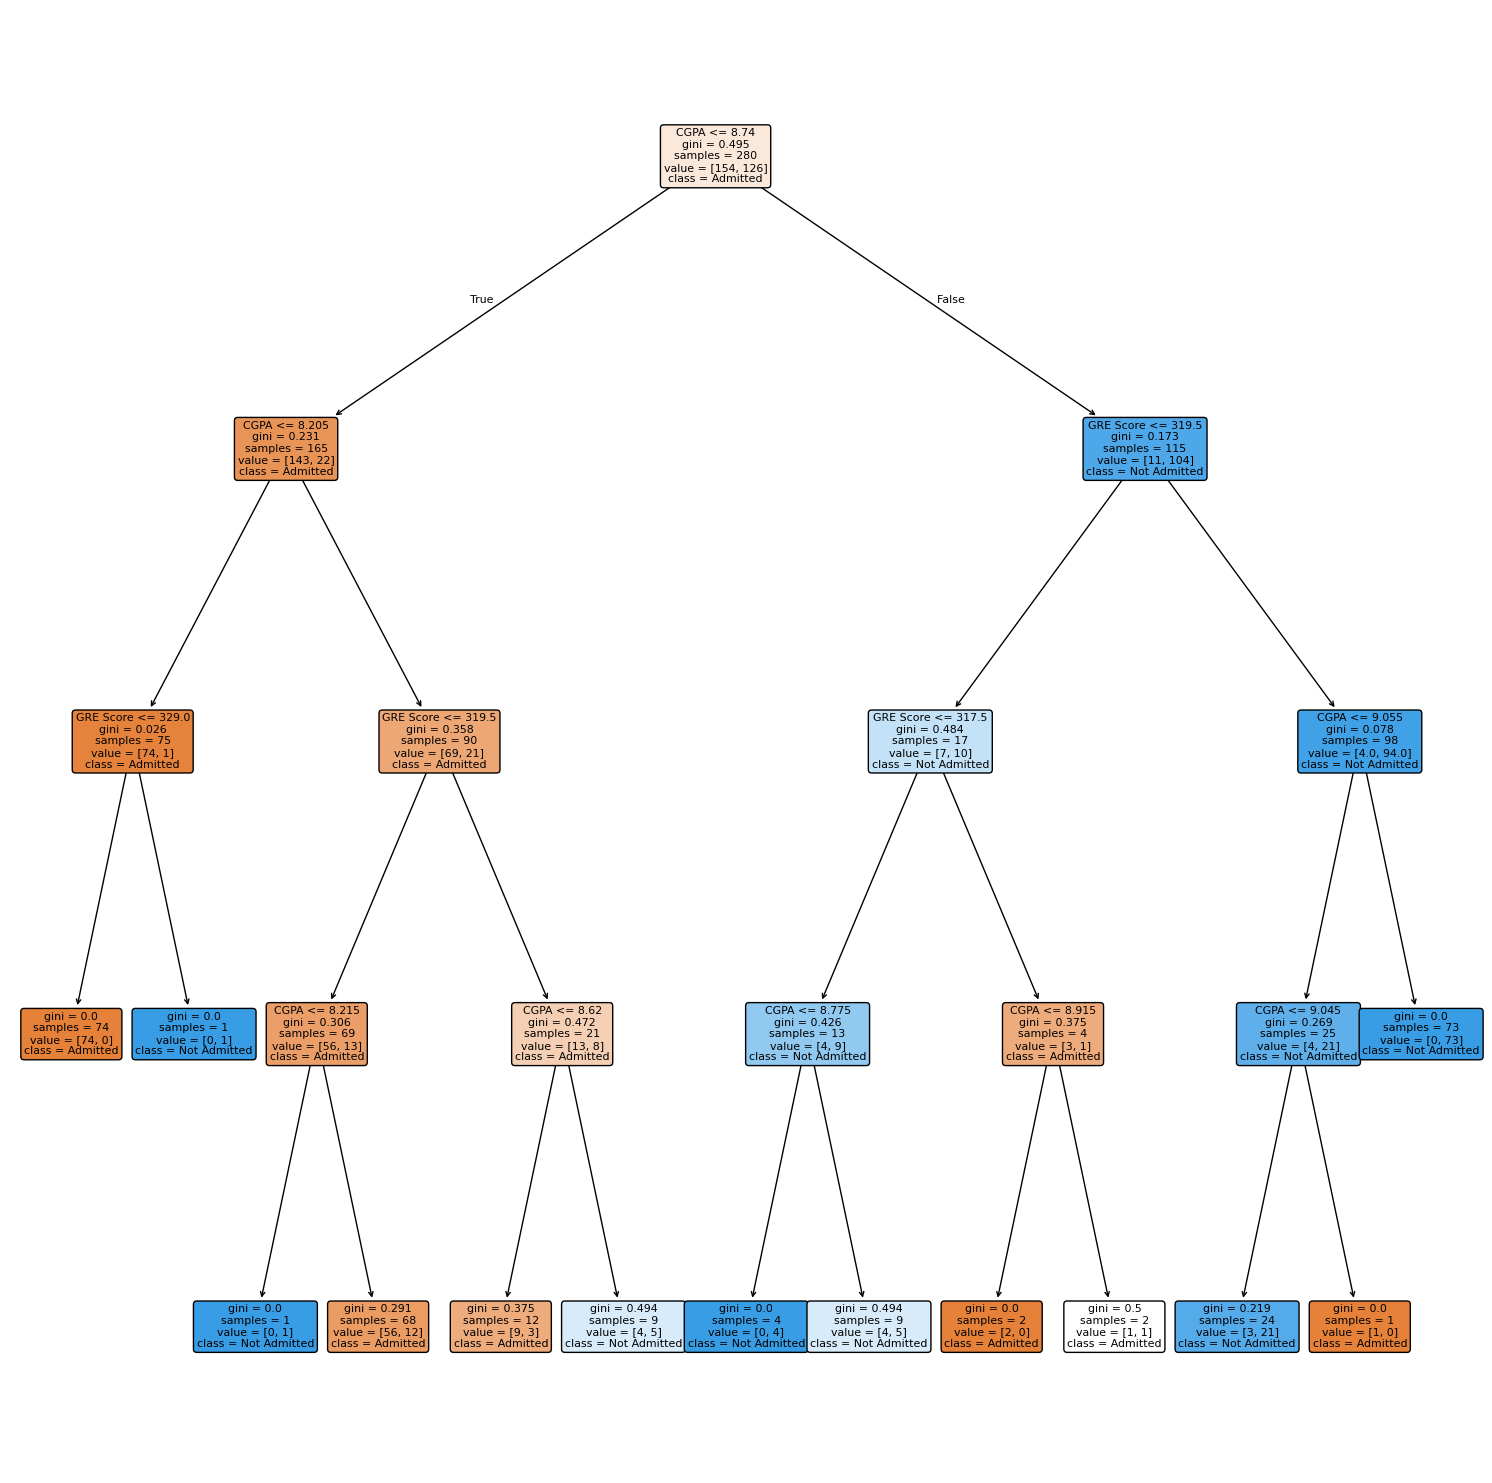

In [18]:
plt.figure(figsize =(19,19))
plot_tree(gini_classifier , feature_names = x.columns,rounded = True , filled = True , impurity = True, class_names =['Admitted','Not Admitted'])
plt.show()